## Collection of ENSO phase specific diagnostics for use in papers and elsewhere
### - Plots linear rgression feedbacks for 2D fields
### - (Add feddbacks to 3D fields)
### - (Add RWS calculation).

In [55]:
import os
os.environ["DASK_TEMPORARY_DIRECTORY"] = "/glade/derecho/scratch/rneale/dask-temp"

import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import cartopy.crs as ccrs

from scipy.stats import linregress
from windspharm.xarray import VectorWind

import importlib
import re

import enso_feedbacks_utils as mypy
from scipy.interpolate import UnivariateSpline
from scipy.ndimage import gaussian_filter
import matplotlib.transforms as mtransforms
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter


In [56]:
from dask.distributed import Client
from dask_jobqueue import PBSCluster

In [57]:
cluster = PBSCluster(
    account="P03010039",
    interface="ext",
    walltime="12:00:00",
    queue="main",
    cores=4,
    memory="32GB",
    processes=4,
    local_directory="/glade/derecho/scratch/rneale/dask-temp",
    job_script_prologue=[
        "mkdir -p /glade/derecho/scratch/rneale/dask-temp"
    ],
)


cluster.scale(jobs=32)
client = Client(cluster)

client

## Setup Run Information

/glade/work/rneale/conda-envs/neale_vproc2/lib/python3.14/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 34061 instead
  warnings.warn(
/glade/work/rneale/conda-envs/neale_vproc2/lib/python3.14/contextlib.py:148: UserWarning: Creating scratch directories is taking a surprisingly long time. (1.02s) This is often due to running workers on a network file system. Consider specifying a local-directory to point workers to write scratch data to a local disk.
  next(self.gen)


Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: /node/crhtc108.hpc.ucar.edu/19080/proxy/34061/status,
Dashboard: /node/crhtc108.hpc.ucar.edu/19080/proxy/34061/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.216:41781,Workers: 0
Dashboard: /node/crhtc108.hpc.ucar.edu/19080/proxy/34061/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [58]:
''' CASE SPECIFICATIONS '''

loop_icases = 7  # Number of set cases to run.
# ── To run without CESM3,  set loop_icases = 6 ──────────────────────────────
# ── To run without E3SMv3, set loop_icases = 5 ──────────────────────────────
# ── To run only obs + CESM2, set loop_icases = 3 ────────────────────────────

fig_pref_user = 'cesm26'   # prepended to ALL png output filenames (leave blank for none)\n
kde_bw = 0.3   # KDE bandwidth for 1D PDFs — larger = smoother (0.25 was noisy)\n


enso_cases = ['OBS','OBS','CESM2','CESM1','E3SMv2','E3SMv3','CESM3']
enso_names = [['ERA5','ERA5'],['MERRA2','MERRA2'],'b.e21.BHISTcmip6.f09_g17.LE2-1001.001',
              'b.e11.B20TRC5CNBDRD.f09_g16.001','v2.FV1.historical_0101','v3.LR.historical.en00',
              'b.e30_alpha08b.BHISTC_LTso.ne30_t232_wgx3.315']  # CESM3: representative (first) member


# Year ranges — CESM3 can be set independently from other cases
enso_ystart = [1980, 1980, 1920, 1920, 1920, 1920, 1920]
enso_yend   = [2023, 2023, 2005, 2005, 2005, 2005, 2005]

#enso_ystart = [1980, 1980, 1979, 1979, 1979, 1979, 1979]
#enso_yend   = [2023, 2023, 2005, 2005, 2005, 2005, 2005]



#enso_cases = ['OBS','OBS','CESM2','CESM1','CAM6','CAM5']
#enso_names = [['ERA5','ERA5'],['MERRA2','MERRA2'],
#              'b.e21.BHISTcmip6.f09_g17.LE2-1001.001','b.e11.B20TRC5CNBDRD.f09_g16.001',
#              'f.e21.FHIST_BGC.f09_f09.historical.ersstv5.goga.ens01','f.e11.FAMIPC5CN.f09_f09.historical.ersstv3b.toga.ens01']
             


# Year ranges — CESM3 can be set independently from other cases
#enso_ystart = [1980, 1980, 1920, 1920, 1920, 1920]
#enso_yend   = [2023, 2023, 2005, 2005, 2005, 2005]



# ── CESM3: explicit ensemble case list ────────────────────────────────────────
# Each entry is an independent run (not auto-generated from a base case).
# Data path: /glade/derecho/scratch/hannay/archive/{case}/atm/hist/
#       or : /glade/derecho/scratch/gmarques/archive/{case}/atm/hist/
# Add or remove case names freely; enso_n_members[6] is set automatically from this list.
cesm3_cases = [
    'b.e30_alpha08b.BHISTC_LTso.ne30_t232_wgx3.315',
    'b.e30_alpha08b.BHISTC_LTso.ne30_t232_wgx3.316',  # add more members here
]


# ── Ensemble members for the binned-line plot ────────────────────────────────
# Set n > 0 to load n members for that case and plot them as individual lines
# (with the ensemble mean as a thick line).  0 = plot single representative member.
# Uses make_ensemble_names() auto-detection:
#   CESM1      → trailing .NNN increments from .001
#   CESM2 cmip6 → BHISTcmip6 LE2-MMMM.NNN: hardcoded 50-member list
#   CESM2 other → LE2-MMMM.NNN; cesm2_members_per_macro / cesm2_macro_step control grouping
#   E3SMv2     → trailing _NNNN increments by e3sm_step (default 10)
#   E3SMv3     → trailing .enNN increments from parsed start
#   CESM3      → uses cesm3_cases list directly (no auto-generation)
enso_n_members = [0, 0, 1, 1, 1, 1, len(cesm3_cases)]   # one entry per enso_cases

# Optional kwargs passed to make_ensemble_names() (not used for CESM3):
enso_ens_kwargs = [
    {},                               # OBS (ERA5)
    {},                               # OBS (MERRA2)
    {},                               # CESM2 BHISTcmip6 (auto-detected, no extra kwargs needed)
    {},                               # CESM1
    {'e3sm_step': 10},                # E3SMv2
    {},                               # E3SMv3
    {},                               # CESM3 (not used; cesm3_cases list is used directly)
]

fig_pref = 'test_f_20th'

xnino_reg = 'nino4' ; ynino_reg = 'nino4'

#season = 'DJF' ; get_months = [12,1,2]
season = 'NDJFM' ; get_months = [11,12,1,2,3]
#season = 'ANN' ; get_months = [1,2,3,4,5,6,7,8,9,10,11,12]

# Select analysis

l1d_plot         = True
lsst_lag_plot  = True   # SST lag correlation maps (lag -3/0/+3 months)
l3d_plot         = True
l3d_latlon       = True
lrws_plot        = True
ltd_plot         = True
lz500_scatter    = True   # Z500 max/min in a region vs Nino3.4 SSTA scatter plot

div_smooth_sigma    = 1.5    # Gaussian sigma (grid pts) applied to composite U/V before div; 0 = off
rws_smooth_sigma    = 1.5    # Gaussian sigma (grid pts) applied to RWS composite before plotting; 0 = off
z500_scatter_region = 'Boreal' # Region for Z500 seasonal max/min scatter (40-75N, 190-280E)

lread_in_all_hist = False   # Read in all the CESM/CAM history files in a directory (max out for 100 years)

lwrite_ts_file = False  # Write out a timeseries of 2D SST/VAR variables (if they don't exist)
lread_ts_file  = False  # Read in a timeseries of 2D SST/VAR variables (if they exist).

ncases = len(enso_cases)

is_in_situ = False  # For real, non-reanalysis observations.

## Grab data and averaged

In [59]:
''' VARIABLE SPECIFICATIONS '''

''' x-var '''
var_x = 'TS'  ; vunits_x = 'K' 
#var_x = 'PRECT' ; vunits_x = 'mm/day' # mon means (m->mm = *1000.)  
#var_y = 'TAUX'  ; vunits_y = 'N/m^2'
#var_comp = 'taux' ; evar_comp = 'chnk' ; ovar_scale = -30.*1.e3 ; cvar_comp = 'TAUX' ; cvar_comp = 'TAUX'; cvar_scale = -1.*1.e3 ;  vunits = 'N/m^2'

''' y-var '''
#var_y = 'OMEGA500'  ; vunits_y = 'mb/hr'
#var_y = 'DIV200'  ; vunits = '/s*'
var_y = 'PRECT' ; vunits_y = 'mm/day' # mon means (m->mm = *1000.)  
#var_y = 'TAUX' ; vunits_y = 'Nm$^{-2}$'
#var_y = 'DTCOND300'  ; vunits_y = 'K/day'

''' 3D '''
var_y3d = 'OMEGA' ;  vunits_y3d='mb/hr'  ; xlim_pdf = [-1,1] ; crange = [-2.,2.]
#var_y3d = 'Q' ;  vunits_y3d='g/kg'  ; xlim_pdf = [-2.,2] ; crange = [-3.,3.]
#var_y3d = 'T' ;  vunits_y3d='K'  ; xlim_pdf = [-2.,2] ; crange = [-3.,3.]
#var_y3d = 'CLOUD' ;  vunits_y3d='%'  ; xlim_pdf = [-2.,2] ; crange = [-25.,25.]
#var_y3d = 'U' ;  vunits_y3d='%'  ; xlim_pdf = [-2.,2] ; crange = [-10.,10.]
#var_y3d = 'RELHUM' ;  vunits_y3d='%'  ; xlim_pdf = [-2.,2] ; crange = [-25.,25.]
#var_y3d = 'DTCOND' ;  vunits_y3d='K/day'  ; xlim_pdf = [-2.,2] ; crange = [-5.,5.]
#var_y3d = 'DCQ' ;  vunits_y3d='g/kg/day'  ; xlim_pdf = [-2.,2] ; crange = [-2,2]

#var_y3d = 'DIV' ;  vunits_y3d='s$^{-1}$*1e$^{6}$'  ; xlim_pdf = [-5.,5] ; crange = [-3.,3.]

#var_y3d = 'RELHUM' ; '%'

''' Lat Lon '''
var_latlon_3d = 'Z3' ; var_latlon_p = 500; vunits_ll = 'm' ; pregion='TropPac'

#var_latlon_3d = 'V' ; var_latlon_p = 850; vunits_ll = 'm/s' ; pregion='TropPac'

# Get correct variable and remove numbers from Z3

var_no_num = re.sub(r"\d+", "", var_latlon_3d)
var_latlon_2d = f"{var_no_num}{int(var_latlon_p)}"




In [60]:
# Initialise collectors for binned-line plot (filled by the main loop below)
collected_binned      = []   # list of (plev x bin) DataArrays, one per case
sst_clim_means        = []   # list of area-weighted mean TS per case
obs_sst_clim          = None # set when icase == 0 (OBS)
collected_z500_scatter = []  # list of dicts with ssta / z500_max / z500_min per case

# Projection for lat-lon plots — fixed per pregion, shared across all cases
ccrs_preg = ccrs.Robinson(central_longitude=180.) if pregion == 'Global' else ccrs.PlateCarree(central_longitude=180.)
# Reference variability contour levels — auto-set from first case, reused for all
_slevels_ref = None
_swidths_ref = None


### Analyzing PRECT nino anomaly dependence on TS nino anomalies
### Analyzing OMEGA nino anomaly dependence on TS nino anomalies


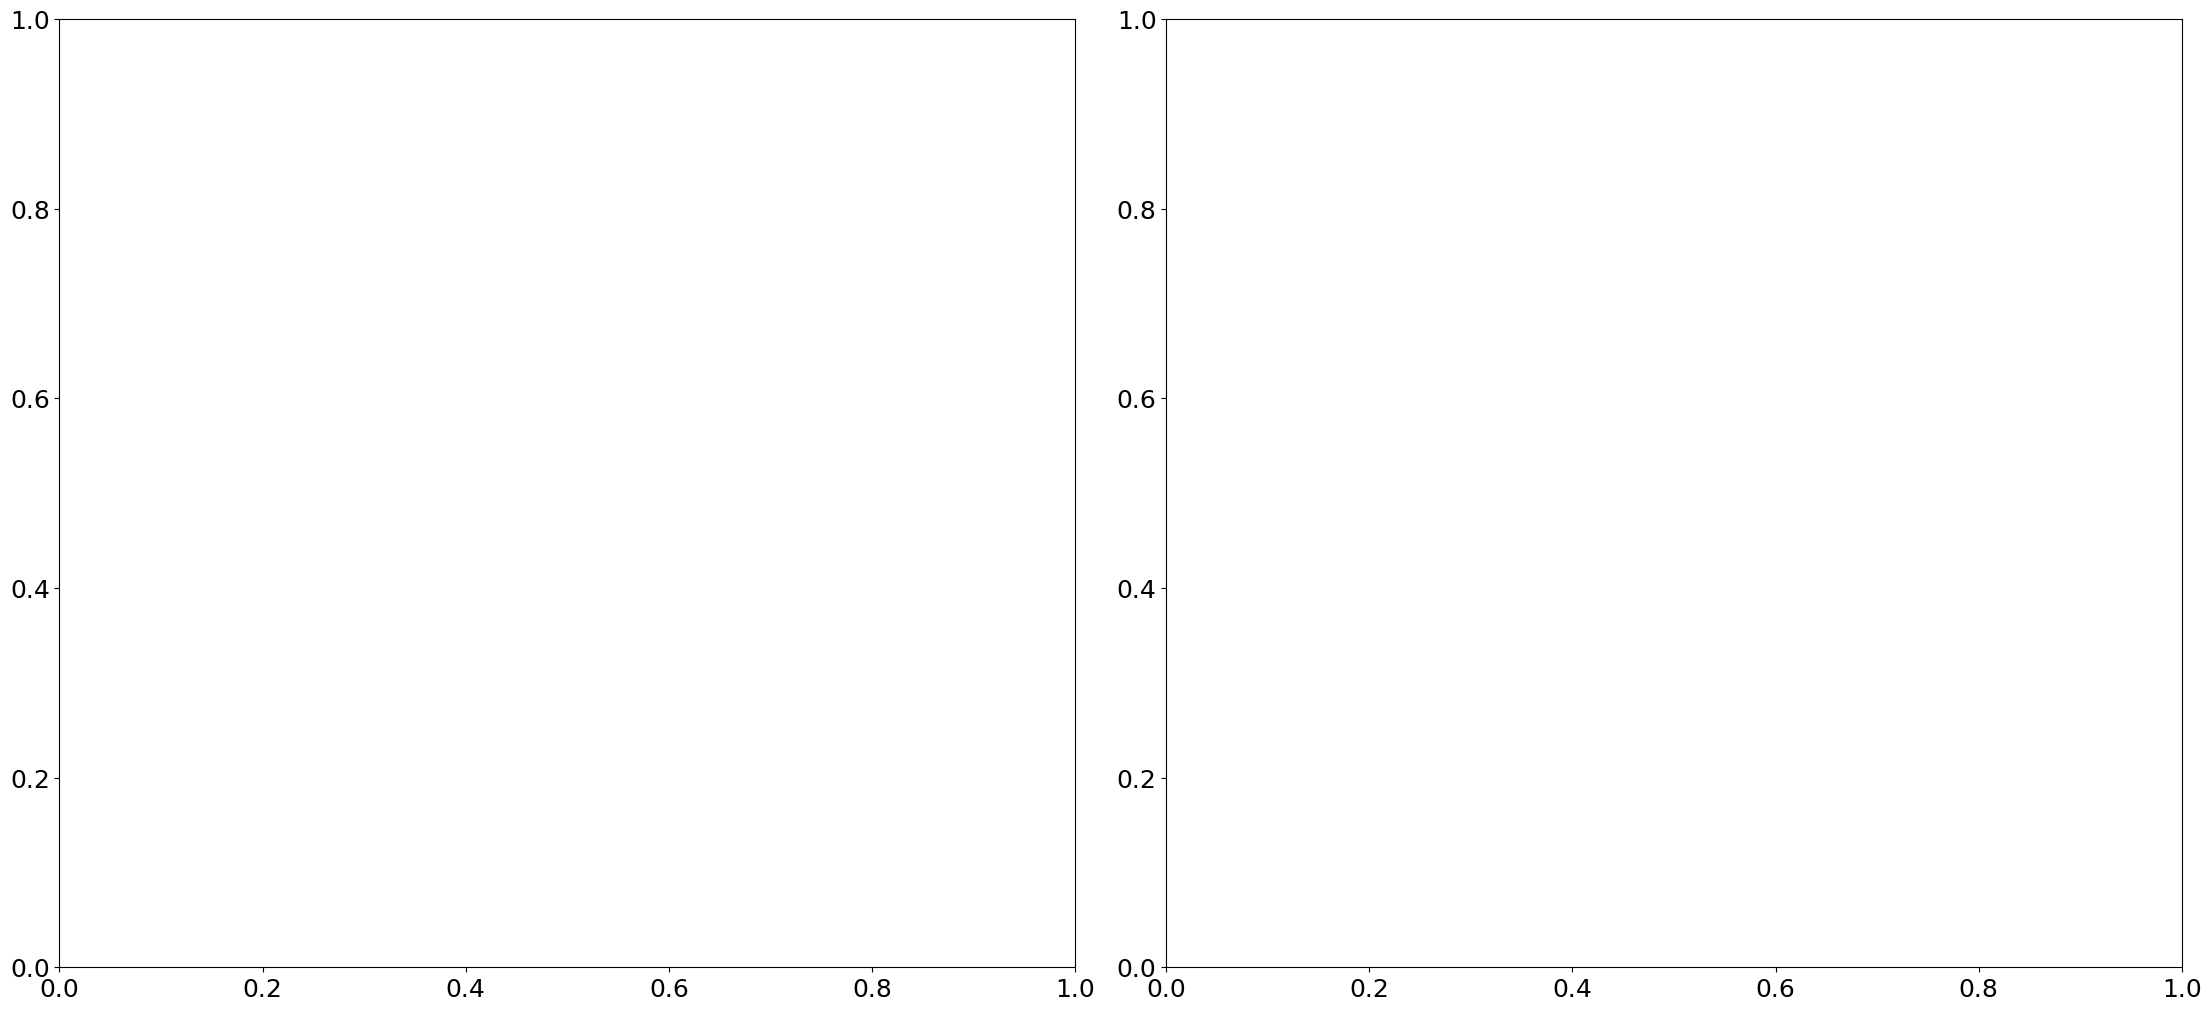

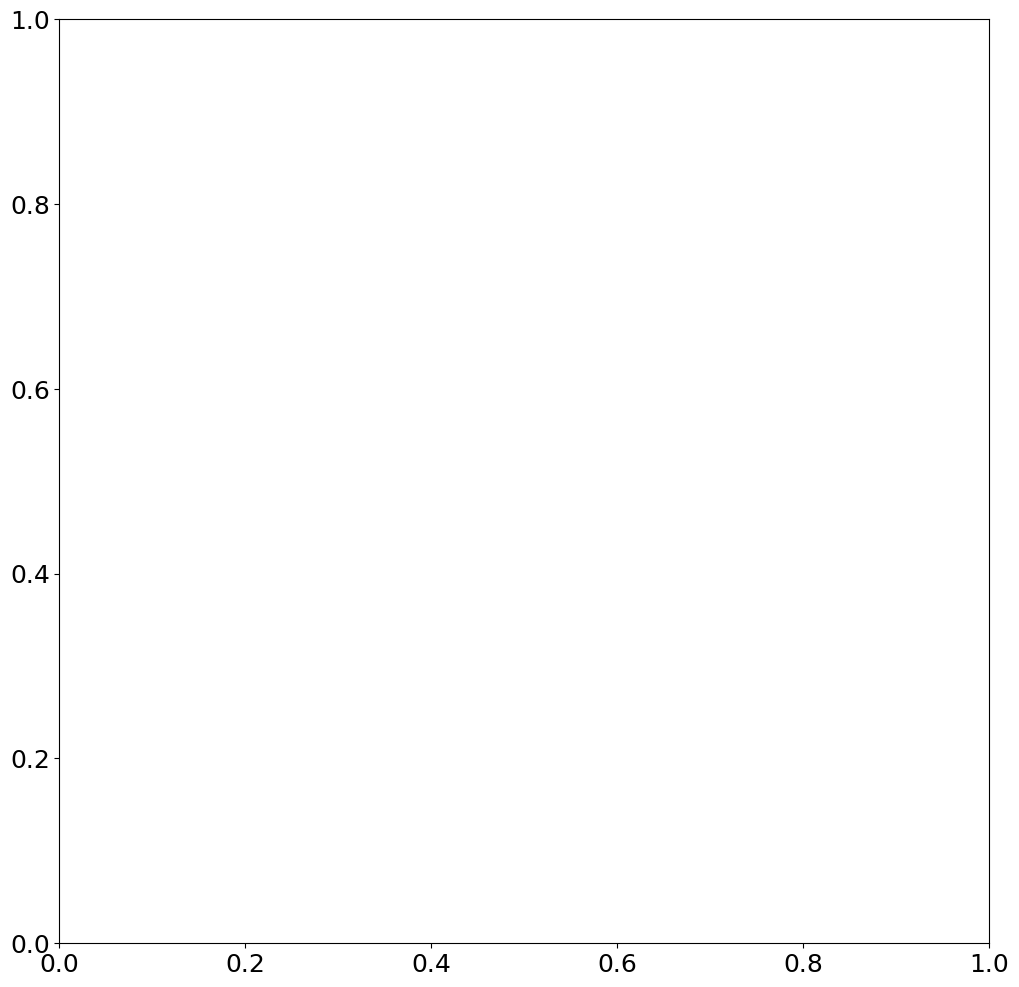

In [61]:
importlib.reload(mypy)

### CHANGE for your own local figure output location
dir_fig = '/glade/u/home/rneale/python/python-figs/papers/ENSO_vprocs_fbacks/'

fscale = 1.0  # Scales figure text globally
figy   = 12
figx   = 12

plt.rcdefaults()
plt.rcParams.update({'font.size': 18 * fscale})

if l1d_plot:
    figp, axp = plt.subplots(
        nrows=1, ncols=2, constrained_layout=True, figsize=(22, 10))
    figs, axs = plt.subplots(
        nrows=1, ncols=1, figsize=(figy, figx))

xmin, xmax, x_avals = mypy.fig_domains(var_x)
ymin, ymax, y_avals = mypy.fig_domains(var_y)

# Build per-case colours, markers, and display names
scat_cols, scat_markers, scat_display_names = mypy.build_case_styles(
    enso_names, enso_cases, loop_icases)

print('### Analyzing', var_y, 'nino anomaly dependence on', var_x, 'nino anomalies')
print('### Analyzing', var_y3d, 'nino anomaly dependence on', var_x, 'nino anomalies')


In [62]:
'''LOOP OVER CASES'''

for icase, case in enumerate(enso_cases[0:loop_icases]):

    lstyle = '-.' if icase == 1 else '-'
    lmark  = 'o' if mypy.infer_ctype(enso_names[icase]) == 'OBS' else ''

    cname  = enso_names[icase]
    fcname = cname[0] if isinstance(cname, list) else cname

    yr0 = enso_ystart[icase]
    yr1 = enso_yend[icase]

    print('')
    print('+++++++++++++++++++++++++++++++++')
    print([icase + 1], ' of ', [ncases], ' +++ ', enso_names[icase], ' +++')
    print('+++++++++++++++++++++++++++++++++')
    print('-- Reading in data --')

    ctype = mypy.infer_ctype(cname)

    # ── 1. Load data ─────────────────────────────────────────────────────────
    print('')
    print('** 1. Grabbing Case Data')

    cname_xy = cname if isinstance(cname, list) else [cname]

    # Keep da_x_all (all months) so lsst_lag_plot can use it without a re-read
    da_x_all = mypy.get_dataset(cname_xy[0], ctype, var_x, yr0, yr1,
                                lread_in_all_hist, lwrite_ts_file, lread_ts_file)
    da_y     = mypy.get_dataset(cname_xy[-1], ctype, var_y, yr0, yr1,
                                lread_in_all_hist, lwrite_ts_file, lread_ts_file)

    # ── 2. Time trimming ──────────────────────────────────────────────────────
    print('')
    print('** 2. Checking and Trimming Time Dimensions')
    da_x, da_y = mypy.dataset_ts_trim(da_x_all, da_y, yr0, yr1, var_x, var_y, get_months)

    # ── 3. 1D Niño anomalies ──────────────────────────────────────────────────
    print('')
    print('** 3. Calculating 1D Nino Anomalies')

    _prec_vars = {'PRECT', 'PRECC', 'PRECL', 'PRECST', 'PRECS'}
    _kde_bw_x  = 0.25 if var_x in _prec_vars else kde_bw
    _kde_bw_y  = 0.25 if var_y in _prec_vars else kde_bw
    var_x_1d, var_x_pdf = mypy.nino_anom_ts(da_x, xnino_reg, x_avals, kde_bw=_kde_bw_x)
    var_y_1d, var_y_pdf = mypy.nino_anom_ts(da_y, ynino_reg, y_avals, kde_bw=_kde_bw_y)

    var_x_1d = var_x_1d.compute()
    var_y_1d = var_y_1d.compute()
    var_x_1d, var_y_1d = xr.align(var_x_1d, var_y_1d, join='inner')
    print(f'   var_x_1d: {var_x_1d.shape},  var_y_1d: {var_y_1d.shape}')

    # Collect mean Nino3.4 SST for the SST-bias line plot
    _nino_w, _nino_e, _nino_n, _nino_s = mypy.nino_region(xnino_reg)
    _da_x_reg = da_x.sel(lat=slice(_nino_s, _nino_n), lon=slice(_nino_w, _nino_e))
    _wts      = np.cos(np.deg2rad(_da_x_reg.lat))
    _sst_mean = float(_da_x_reg.weighted(_wts).mean(("lat", "lon", "time")).compute())
    sst_clim_means.append(_sst_mean)
    if icase == 0:
        obs_sst_clim = _sst_mean

    # ── 4. 1D PDFs + scatter ──────────────────────────────────────────────────
    if l1d_plot:
        print('')
        print('** 4. Plotting 1D PDFs')

        axp[0].hist(var_x_1d, linewidth=5, color=scat_cols[icase],
                    bins=int(0.5 * var_x_pdf.size), range=(xmin, xmax),
                    alpha=0.3, density=True)
        axp[0].plot(x_avals, var_x_pdf, linewidth=5, color=scat_cols[icase],
                    linestyle=lstyle, label=scat_display_names[icase])

        axp[1].hist(var_y_1d, linewidth=5, color=scat_cols[icase],
                    bins=int(0.5 * var_y_pdf.size), range=(ymin, ymax),
                    alpha=0.3, density=True)
        axp[1].plot(y_avals, var_y_pdf, linewidth=5, color=scat_cols[icase],
                    linestyle=lstyle, label=scat_display_names[icase])

        axp[0].set_xlim([xmin, xmax]); axp[1].set_xlim([ymin, ymax])
        axp[0].set_title(var_x + ' PDF (' + xnino_reg + ') - ' + season)
        axp[1].set_title(var_y + ' PDF (' + ynino_reg + ') - ' + season)
        axp[0].set_xlabel(vunits_x); axp[1].set_xlabel(vunits_y)
        axp[0].set_ylabel('Density'); axp[1].set_ylabel('Density')
        axp[0].grid(True); axp[1].grid(True)
        axp[0].axvline(x=0., color='gray', linestyle='--', linewidth=2.5)
        axp[1].axvline(x=0., color='gray', linestyle='--', linewidth=2.5)
        axp[0].legend(); axp[1].legend()

        print('')
        print('** 5. Calculating and Plotting 1D Lag Regress')

        varx_even = np.linspace(xmin, xmax, 100)
        _do_nlr   = (var_x == "TS" and var_y == "PRECT")
        if _do_nlr:
            _sx    = var_x_1d.values
            _sy    = var_y_1d.values
            _sord  = np.argsort(_sx)
            _spline = UnivariateSpline(_sx[_sord], _sy[_sord], k=3, s=10 * len(_sx))
            line   = _spline(varx_even)
            fit_label_val = "spline"
            print(f"   Spline fit: {_spline.get_knots().size} knots")
        else:
            from scipy.stats import linregress
            slope, intercept, r_value, p_value, std_err = linregress(var_x_1d, var_y_1d)
            fit_label_val = f"{slope:.3g}"
            line = slope * varx_even + intercept

        case_yrs = scat_display_names[icase] + ' [' + str(int(yr0)) + '-' + str(int(yr1)) + '] ' + fit_label_val
        axs.scatter(var_x_1d, var_y_1d, label=case_yrs, alpha=0.2, color=scat_cols[icase], s=12)

        _xmask       = (varx_even >= -2.0) if _do_nlr else np.ones(len(varx_even), dtype=bool)
        _line_clipped = np.clip(line[_xmask], ymin, ymax)
        axs.plot(varx_even[_xmask], _line_clipped, color=scat_cols[icase],
                 linewidth=3, linestyle='-' if _do_nlr else lstyle, zorder=5)

        axs.set_xlabel(var_x + ' (' + vunits_x + ')'); axs.set_xlim([xmin, xmax])
        axs.set_ylabel(var_y + ' (' + vunits_y + ')'); axs.set_ylim([ymin, ymax])
        axs.set_title(('Exp Fit' if _do_nlr else 'Linear Regression') + ' ' +
                      var_x + ' (' + xnino_reg + ') with ' + var_y + ' (' + ynino_reg + ') - ' + season)

        if icase == ncases - 1:
            legend = axs.legend(title='Case/Years/Slope|Rate')
            legend.get_title().set_fontweight('bold')
            for ileg, leg_lab in enumerate(legend.get_texts()):
                leg_lab.set_color(scat_cols[ileg])

        axs.grid(True)
        axs.axhline(0, color='gray', linestyle='--', linewidth=2.5)
        axs.axvline(0, color='gray', linestyle='--', linewidth=2.5)

    # ── 5b. SST lag correlation maps ─────────────────────────────────────────
    if lsst_lag_plot:
        print('')
        print('** 5b. SST Lag Correlation Maps (-6 / 0 / +6 months)')
        # da_x_all is all-month SST loaded above — no re-read needed
        mypy.plot_sst_lag_corr_maps(
            da_x_all, xnino_reg, fcname, yr0, yr1,
            dir_fig, fig_pref_user, fscale)

    # ── 6-10. 3D binned analysis ─────────────────────────────────────────────
    if l3d_plot:
        print('')
        print('** 6. 3D: Reading Data')

        fig_zp, ax_zp = plt.subplots(nrows=1, ncols=1, figsize=(figy, figx))
        fig_zm, ax_zm = plt.subplots(nrows=1, ncols=1, figsize=(figy, figx))

        if var_y3d == "DIV" and case != 'OBS':
            print(' -Divergence from CESM U and V')
            da_u3d = mypy.get_dataset(cname_xy[-1], ctype, 'U', yr0, yr1,
                                      lread_in_all_hist, lwrite_ts_file, lread_ts_file)
            da_v3d = mypy.get_dataset(cname_xy[-1], ctype, 'V', yr0, yr1,
                                      lread_in_all_hist, lwrite_ts_file, lread_ts_file)
            da_y3d = mypy.calc_div(da_u3d, da_v3d)
        else:
            da_y3d = mypy.get_dataset(cname_xy[-1], ctype, var_y3d, yr0, yr1,
                                      lread_in_all_hist, lwrite_ts_file, lread_ts_file)

        print('')
        print('** 7. 3D: Checking and Trimming Time Dimensions')
        _, da_y3d = mypy.dataset_ts_trim(da_x, da_y3d, yr0, yr1, var_x, var_y, get_months)

        print('')
        print('** 8. 3D: Calculating 3D Nino Anomalies')
        var_y_3d, var_y_pdf3d = mypy.nino_anom_ts(da_y3d, ynino_reg, y_avals, kde_bw=_kde_bw_y)

        print('** 9. 3D: Plot PDFs: Overlayed for each pressure level.')
        nlevels   = 12
        full_cmap = plt.get_cmap('gist_rainbow_r')
        cmap      = full_cmap(np.linspace(0, 1, nlevels))
        plev_range = [100., 1000.]
        plev_plot  = (var_y_pdf3d.plev > plev_range[0]) & (var_y_pdf3d.plev < plev_range[1])

        for il, lev in enumerate(var_y_pdf3d.plev.where(plev_plot, drop=True).values):
            ax_zp.plot(var_y_pdf3d.axis, var_y_pdf3d.sel(plev=lev),
                       label=f"{int(lev)} hPa")

        ax_zp.text(0.01, 0.99, fcname + ' (' + str(yr0) + '-' + str(yr1) + ')',
                   transform=ax_zm.transAxes, ha="left", va="top",
                   fontweight="bold", fontsize=10 * fscale)
        ax_zp.set_title(r"$\bf{" + case + "}$ - " + var_y3d + " PDF (" + ynino_reg + ")")
        ax_zp.set_xlabel(vunits_y3d)
        ax_zp.set_ylabel('Density')
        ax_zp.set_xlim(xlim_pdf)
        ax_zp.grid(True)
        ax_zp.axvline(x=0., color='gray', linestyle='--', linewidth=2.5)
        ax_zp.legend()

        print('** 10. 3D: Mean of Points With Height')
        nlevels  = 20
        dlev_b   = (xmax - xmin) / nlevels
        bins     = np.arange(xmin, xmax + dlev_b, dlev_b)
        bin_centers = 0.5 * (bins[:-1] + bins[1:])

        _x_aln, _y_aln = xr.align(var_x_1d, var_y_3d, join='inner')
        print(f'   Binning {len(_x_aln)} individual monthly values')
        binned, binned_var, bin_counts = mypy.bin_mean_var_by_level(
            _y_aln, _x_aln, bins, bin_centers)
        collected_binned.append(binned)

        # ── Ensemble members ────────────────────────────────────────────────
        _n_mem       = enso_n_members[icase] if icase < len(enso_n_members) else 0
        _ens_kwargs  = enso_ens_kwargs[icase] if icase < len(enso_ens_kwargs) else {}
        _member_binned = []
        if _n_mem > 0 and ctype != 'OBS':
            print(f'   ** Ensemble: loading {_n_mem} members ...')
            _member_names = (list(cesm3_cases) if ctype == 'cesm3' and cesm3_cases
                             else mypy.make_ensemble_names(fcname, _n_mem, **_ens_kwargs))
            for _mcase in _member_names:
                print(f'      {_mcase}')
                try:
                    _da_x_m = mypy.get_dataset(_mcase, ctype, var_x, yr0, yr1,
                                               lread_in_all_hist, False, lread_ts_file)
                    if var_y3d == 'DIV' and ctype != 'OBS':
                        _da_u_m   = mypy.get_dataset(_mcase, ctype, 'U', yr0, yr1,
                                                     lread_in_all_hist, lwrite_ts_file, lread_ts_file)
                        _da_v_m   = mypy.get_dataset(_mcase, ctype, 'V', yr0, yr1,
                                                     lread_in_all_hist, lwrite_ts_file, lread_ts_file)
                        _da_y3d_m = mypy.calc_div(_da_u_m, _da_v_m)
                    else:
                        _da_y3d_m = mypy.get_dataset(_mcase, ctype, var_y3d, yr0, yr1,
                                                     lread_in_all_hist, lwrite_ts_file, lread_ts_file)
                    _da_x_m, _da_y3d_m = mypy.dataset_ts_trim(
                        _da_x_m, _da_y3d_m, yr0, yr1, var_x, var_y3d, get_months)
                    _var_x_1d_m, _ = mypy.nino_anom_ts(_da_x_m, xnino_reg, x_avals, kde_bw=_kde_bw_x)
                    _var_y3d_m, _  = mypy.nino_anom_ts(_da_y3d_m, ynino_reg, y_avals, kde_bw=_kde_bw_y)
                    _x_m, _y_m     = xr.align(_var_x_1d_m, _var_y3d_m, join='inner')
                    _b_m, _, _     = mypy.bin_mean_var_by_level(_y_m, _x_m, bins, bin_centers)
                    _member_binned.append(_b_m)
                except Exception as _e:
                    print(f'      Skipping {_mcase}: {_e}')
            if _member_binned:
                collected_binned[-1] = _member_binned
                print(f'   ** Ensemble: {len(_member_binned)} members loaded')

        binned_plot = (xr.concat(_member_binned, dim='member').mean('member')
                       if _member_binned else binned)

        # Contour levels
        dlev_p = (crange[1] - crange[0]) / nlevels
        levels = np.arange(crange[0], crange[1] + dlev_p, dlev_p)

        # Auto-set variability contour levels from first case
        if _slevels_ref is None:
            _vmax = float(np.nanpercentile(binned_var.values, 90))
            if _vmax > 0:
                _mag  = 10 ** np.floor(np.log10(_vmax / 4))
                _step = np.round(_vmax / (4 * _mag)) * _mag
                _step = max(_step, _mag)
                _slevels_ref = np.arange(_step, _vmax * 1.05, _step)
            else:
                _slevels_ref = np.array([0.1, 0.2, 0.4, 1., 1.5, 2.])
            _swidths_ref = np.ones(len(_slevels_ref), dtype=int)
            _swidths_ref[len(_slevels_ref) // 2:] = 2
            print(f'   Variability contour levels (auto): {_slevels_ref}')

        cf = ax_zm.contourf(binned_plot.bin, binned_plot.plev, binned_plot,
                            levels=levels, cmap="RdBu_r", extend="both")
        plt.colorbar(cf, ax=ax_zm, label="Anomaly (" + vunits_y3d + ")")

        cf = ax_zm.contour(binned_plot.bin, binned_plot.plev, binned_var,
                           levels=_slevels_ref, linewidths=_swidths_ref, colors='black')
        ax_zm.clabel(cf, fontsize=12)

        if _member_binned:
            _bm = _member_binned[0]
            ax_zm.contour(_bm.bin, _bm.plev, _bm,
                          levels=np.array([-1., -0.5, 0.5, 1.]),
                          colors=['royalblue', 'royalblue', 'firebrick', 'firebrick'],
                          linewidths=0.5, alpha=0.35, linestyles=['--', '--', '-', '-'])

        ax_zm.invert_yaxis()
        ax_zm.set_xlim([xmin, xmax])
        ax_zm.set_xlabel(f"{xnino_reg} {var_x} anomaly ({vunits_x})", usetex=False)
        ax_zm.set_ylabel("Pressure (hPa)")

        _ens_label = f' [ens. mean, N={len(_member_binned)}]' if _member_binned else ''
        ax_zm.text(0.01, 0.99, fcname + ' (' + str(yr0) + '-' + str(yr1) + ')' + _ens_label,
                   transform=ax_zm.transAxes, ha="left", va="top",
                   fontweight="bold", fontsize=10 * fscale)
        ax_zm.set_title(r"$\bf{" + case + r"}$ - " + var_y3d + " " + ynino_reg +
                        " anomalies by pressure - " + season, usetex=False)
        ax_zm.axvline(x=0., color='gray', linestyle='--', linewidth=2.5)

        _blended = mtransforms.blended_transform_factory(ax_zm.transData, ax_zm.transAxes)
        _total   = bin_counts.sum()
        for _bc, _cnt in zip(bin_centers, bin_counts):
            _pct = 100.0 * _cnt / _total if _total > 0 else 0.0
            ax_zm.text(_bc, 0.02, f'{_pct:.0f}%', transform=_blended,
                       ha='center', va='bottom', fontsize=7 * fscale,
                       color='red' if _cnt == 0 else 'darkgreen', fontweight='bold')

        _fstem = (fig_pref_user + '_' if fig_pref_user else '') + fcname + '_' + var_x + '_' + var_y3d + '_' + season + '_' + xnino_reg + '_' + ynino_reg
        fig_zp.savefig(dir_fig + _fstem + '_plev_PDF_monthly.png')
        fig_zm.savefig(dir_fig + _fstem + '_plev_monthly.png')
        fig_zp.show(); fig_zm.show()
        plt.close(fig_zp); plt.close(fig_zm)

    # ── 11-14. 2D lat-lon composites ─────────────────────────────────────────
    if l3d_latlon:
        print('')
        print('** 11. 2D lat-lon: Checking and Trimming Time Dimensions')

        fig_llo, ax_llo = plt.subplots(1, 1, figsize=(figy, figx),
                                       subplot_kw={'projection': ccrs_preg},
                                       constrained_layout=True)
        fig_lla, ax_lla = plt.subplots(1, 1, figsize=(figy, figx),
                                       subplot_kw={'projection': ccrs_preg},
                                       constrained_layout=True)

        if var_latlon_3d == "DIV" and case != 'OBS':
            da_u3d = mypy.get_dataset(cname_xy[-1], ctype, 'U', yr0, yr1,
                                      lread_in_all_hist, lwrite_ts_file, lread_ts_file)
            da_v3d = mypy.get_dataset(cname_xy[-1], ctype, 'V', yr0, yr1,
                                      lread_in_all_hist, lwrite_ts_file, lread_ts_file)
            da_y3d = mypy.calc_div(da_u3d, da_v3d)
        else:
            da_y3d = mypy.get_dataset(cname_xy[-1], ctype, var_latlon_3d, yr0, yr1,
                                      lread_in_all_hist, lwrite_ts_file, lread_ts_file)

        plot_latlon = da_y3d.sel(plev=var_latlon_p, method='nearest').squeeze(drop=True)

        print('')
        print('** 12. 2D lat-lon: Checking and Trimming Time Dimensions')
        _, plot_latlon = mypy.dataset_ts_trim(da_x, plot_latlon, yr0, yr1, var_x, var_y, get_months)

        print('')
        print('** 13. 2D lat-lon: Create El Nino / La Nina composites')
        plot_latlon, _var_x_1d_ll = xr.align(plot_latlon, var_x_1d)
        plot_latlon_anom = mypy.monthly_anom(plot_latlon)

        nino_mask        = _var_x_1d_ll >= 1.0
        plot_latlon_nino = plot_latlon_anom.sel(time=nino_mask).mean("time")
        mypy.plot_latlon(ax_llo, fig_llo, icase, var_latlon_2d, plot_latlon_nino, vunits_ll,
                         case, fcname, season, pregion, ynino_reg, False, False, False, fscale,
                         equator_line=True, transparent_zero=True)
        fig_llo.savefig(dir_fig + (fig_pref_user + '_' if fig_pref_user else '') + fcname +
                        '_' + var_x + '_' + var_latlon_2d + '_' + season + '_' + xnino_reg +
                        '_' + ynino_reg + '_latlon_nino_monthly.png')

        nina_mask        = _var_x_1d_ll <= -1.0
        plot_latlon_nina = plot_latlon_anom.sel(time=nina_mask).mean("time")
        mypy.plot_latlon(ax_lla, fig_lla, icase, var_latlon_2d, plot_latlon_nina, vunits_ll,
                         case, fcname, season, pregion, ynino_reg, False, False, False, fscale,
                         equator_line=True, transparent_zero=True)
        fig_lla.savefig(dir_fig + (fig_pref_user + '_' if fig_pref_user else '') + fcname +
                        '_' + var_x + '_' + var_latlon_2d + '_' + season + '_' + xnino_reg +
                        '_' + ynino_reg + '_latlon_nina_monthly.png')

        fig_llo.show(); fig_lla.show()
        plt.close(fig_llo); plt.close(fig_lla)

    # ── 15. Rossby Wave Source ────────────────────────────────────────────────
    if lrws_plot:
        print('')
        print('** 15. RWS: Rossby Wave Source at 200 hPa')

        rws_plev = 200
        da_u_rws = mypy.get_dataset(cname_xy[-1], ctype, 'U', yr0, yr1,
                                    lread_in_all_hist, lwrite_ts_file, lread_ts_file)
        da_v_rws = mypy.get_dataset(cname_xy[-1], ctype, 'V', yr0, yr1,
                                    lread_in_all_hist, lwrite_ts_file, lread_ts_file)
        da_u_rws = da_u_rws.sel(plev=rws_plev, method='nearest').squeeze()
        da_v_rws = da_v_rws.sel(plev=rws_plev, method='nearest').squeeze()
        _, da_u_rws = mypy.dataset_ts_trim(da_x, da_u_rws, yr0, yr1, var_x, 'U', get_months)
        _, da_v_rws = mypy.dataset_ts_trim(da_x, da_v_rws, yr0, yr1, var_x, 'V', get_months)

        da_rws      = mypy.calc_rws(da_u_rws, da_v_rws).compute()
        da_rws_anom = mypy.monthly_anom(da_rws)
        da_rws_anom, var_x_rws = xr.align(da_rws_anom, var_x_1d)

        nino_mask_rws = var_x_rws >= 1.0
        nina_mask_rws = var_x_rws <= -1.0
        rws_nino = da_rws_anom.sel(time=nino_mask_rws).mean("time") * 1e11
        rws_nina = da_rws_anom.sel(time=nina_mask_rws).mean("time") * 1e11

        if rws_smooth_sigma > 0:
            rws_nino = xr.DataArray(gaussian_filter(rws_nino.values, sigma=rws_smooth_sigma),
                                    coords=rws_nino.coords, dims=rws_nino.dims)
            rws_nina = xr.DataArray(gaussian_filter(rws_nina.values, sigma=rws_smooth_sigma),
                                    coords=rws_nina.coords, dims=rws_nina.dims)

        rws_levels = np.array([-10., -8., -6., -4., -2., -1., 0., 1., 2., 4., 6., 8., 10.])
        fig_rws_p, ax_rws_p = plt.subplots(1, 1, figsize=(figy, figx),
                                            subplot_kw={'projection': ccrs_preg},
                                            constrained_layout=True)
        fig_rws_m, ax_rws_m = plt.subplots(1, 1, figsize=(figy, figx),
                                            subplot_kw={'projection': ccrs_preg},
                                            constrained_layout=True)

        mypy.plot_latlon(ax_rws_p, fig_rws_p, icase, f'RWS{rws_plev}', rws_nino,
                         r'$\times10^{-11}$ s$^{-2}$', case, fcname, season, pregion,
                         xnino_reg, False, False, False, fscale,
                         levels=rws_levels, mask_thresh=0.05)
        mypy.plot_latlon(ax_rws_m, fig_rws_m, icase, f'RWS{rws_plev}', rws_nina,
                         r'$\times10^{-11}$ s$^{-2}$', case, fcname, season, pregion,
                         xnino_reg, False, False, False, fscale,
                         levels=rws_levels, mask_thresh=0.05)

        _fstem_rws = dir_fig + (fig_pref_user + '_' if fig_pref_user else '') + fcname + '_RWS' + str(rws_plev) + '_' + season + '_' + xnino_reg
        fig_rws_p.savefig(_fstem_rws + '_nino_latlon.png')
        fig_rws_m.savefig(_fstem_rws + '_nina_latlon.png')
        fig_rws_p.show(); fig_rws_m.show()
        plt.close(fig_rws_p); plt.close(fig_rws_m)

    # ── 16. PRECT + divergent wind + divergence composite ────────────────────
    if ltd_plot:
        print('')
        print('** 16. PRECT / Divergent wind / Divergence composite')

        td_plev = 200
        da_u_td = mypy.get_dataset(cname_xy[-1], ctype, 'U', yr0, yr1,
                                   lread_in_all_hist, lwrite_ts_file, lread_ts_file)
        da_v_td = mypy.get_dataset(cname_xy[-1], ctype, 'V', yr0, yr1,
                                   lread_in_all_hist, lwrite_ts_file, lread_ts_file)
        da_u_td = da_u_td.sel(plev=td_plev, method='nearest').squeeze()
        da_v_td = da_v_td.sel(plev=td_plev, method='nearest').squeeze()
        _, da_u_td = mypy.dataset_ts_trim(da_x, da_u_td, yr0, yr1, var_x, 'U', get_months)
        _, da_v_td = mypy.dataset_ts_trim(da_x, da_v_td, yr0, yr1, var_x, 'V', get_months)

        da_prect_td = mypy.get_dataset(cname_xy[-1], ctype, 'PRECT', yr0, yr1,
                                       lread_in_all_hist, lwrite_ts_file, lread_ts_file)
        _, da_prect_td = mypy.dataset_ts_trim(da_x, da_prect_td, yr0, yr1, var_x, 'PRECT', get_months)

        u_anom_td     = mypy.monthly_anom(da_u_td)
        v_anom_td     = mypy.monthly_anom(da_v_td)
        prect_anom_td = mypy.monthly_anom(da_prect_td)

        u_anom_td,     var_x_td = xr.align(u_anom_td,     var_x_1d)
        v_anom_td,     _        = xr.align(v_anom_td,     var_x_td)
        prect_anom_td, _        = xr.align(prect_anom_td, var_x_td)

        nino_mask_td = var_x_td >= 1.0
        nina_mask_td = var_x_td <= -1.0

        def _comp(da, mask):
            return da.sel(time=mask).mean("time")

        for comp_label, comp_mask in [('nino', nino_mask_td), ('nina', nina_mask_td)]:
            prect_comp = _comp(prect_anom_td, comp_mask)
            u_comp     = _comp(u_anom_td,     comp_mask).compute()
            v_comp     = _comp(v_anom_td,     comp_mask).compute()

            if div_smooth_sigma > 0:
                u_comp = xr.DataArray(
                    gaussian_filter(u_comp.values, sigma=div_smooth_sigma),
                    coords=u_comp.coords, dims=u_comp.dims)
                v_comp = xr.DataArray(
                    gaussian_filter(v_comp.values, sigma=div_smooth_sigma),
                    coords=v_comp.coords, dims=v_comp.dims)

            u_chi_comp, v_chi_comp, div_comp = mypy.calc_div_wind(u_comp, v_comp)
            div_comp = div_comp * 1e6

            preg_area  = mypy.get_pregion(pregion)
            td_lat_min = preg_area['lat_min']; td_lat_max = preg_area['lat_max']
            td_lon_min = preg_area['lon_min']; td_lon_max = preg_area['lon_max']

            def _reg(da):
                return da.sortby('lat').sel(lat=slice(td_lat_min, td_lat_max),
                                            lon=slice(td_lon_min, td_lon_max))

            prect_plot = _reg(prect_comp)
            u_chi_plot = _reg(u_chi_comp)
            v_chi_plot = _reg(v_chi_comp)
            div_plot   = _reg(div_comp)

            dpproj = ccrs.PlateCarree()
            fig_td, ax_td = plt.subplots(1, 1, figsize=(figy, figx),
                                         subplot_kw={'projection': ccrs_preg},
                                         constrained_layout=True)

            prect_lev_td = np.linspace(-5., 5., 21)
            cf_pr = ax_td.contourf(prect_plot.lon, prect_plot.lat, prect_plot,
                                   levels=prect_lev_td, cmap='BrBG',
                                   extend='both', transform=dpproj)
            cbar_pr = fig_td.colorbar(cf_pr, ax=ax_td, orientation='horizontal',
                                      fraction=0.05, pad=0.08)
            cbar_pr.set_label('PRECT anomaly (mm/day)', fontsize=12 * fscale)

            cs_pos = ax_td.contour(div_plot.lon, div_plot.lat, div_plot,
                                   levels=np.array([0.5, 1., 2., 3.]), colors='black',
                                   linewidths=1.5, linestyles='solid', transform=dpproj)
            cs_neg = ax_td.contour(div_plot.lon, div_plot.lat, div_plot,
                                   levels=np.array([-3., -2., -1., -0.5]), colors='black',
                                   linewidths=1.0, linestyles='dashed', transform=dpproj)
            ax_td.clabel(cs_pos, fontsize=8 * fscale, fmt='%.1f')
            ax_td.clabel(cs_neg, fontsize=8 * fscale, fmt='%.1f')

            qskip  = max(1, len(u_chi_plot.lat) // 15)
            lon2d, lat2d = np.meshgrid(u_chi_plot.lon.values[::qskip],
                                       u_chi_plot.lat.values[::qskip])
            u_q = u_chi_plot.transpose('lat', 'lon').values[::qskip, ::qskip]
            v_q = v_chi_plot.transpose('lat', 'lon').values[::qskip, ::qskip]
            qv  = ax_td.quiver(lon2d, lat2d, u_q, v_q,
                               transform=dpproj, scale=20., width=0.003,
                               color='dimgray', alpha=0.85)
            ax_td.quiverkey(qv, X=0.88, Y=1.03, U=2., label='2 m/s', labelpos='E',
                            fontproperties={'size': 10 * fscale})

            ax_td.coastlines(linewidth=1, color='black', resolution='110m')
            ax_td.gridlines()
            ax_td.add_feature(cfeature.LAND, facecolor='silver', zorder=0)

            if pregion != 'Global':
                ax_td.set_yticks(np.arange(td_lat_min, td_lat_max + 10., 10.), crs=dpproj)
                ax_td.yaxis.set_major_formatter(LatitudeFormatter())
                ax_td.set_xticks(np.arange(td_lon_min, td_lon_max + 30., 30.), crs=dpproj)
                ax_td.xaxis.set_major_formatter(LongitudeFormatter())

            _nw, _ne, _nn, _ns = mypy.nino_region(xnino_reg)
            ax_td.plot([_nw, _ne, _ne, _nw, _nw], [_ns, _ns, _nn, _nn, _ns],
                       transform=dpproj, color='red', linewidth=1.5,
                       linestyle='--', zorder=6)

            lbl = 'El Niño' if comp_label == 'nino' else 'La Niña'
            ax_td.set_title(r"$\bf{" + case + r"}$ - PRECT / χ-wind / DIV" +
                            str(td_plev) + " (" + xnino_reg + ") " + lbl + " - " + season)
            ax_td.text(0.01, 0.99, fcname + ' (' + str(yr0) + '-' + str(yr1) + ')',
                       transform=ax_td.transAxes, ha='left', va='top',
                       fontweight='bold', fontsize=10 * fscale)

            fig_td.savefig(dir_fig + (fig_pref_user + '_' if fig_pref_user else '') + fcname +
                           '_comp_PRECT_chiwind_DIV' + str(td_plev) + '_' + season +
                           '_' + xnino_reg + '_' + comp_label + '_latlon.png')
            fig_td.show()
            plt.close(fig_td)

    # ── 17. Z500 seasonal scatter (data collection) ───────────────────────────
    if lz500_scatter:
        print('')
        print('** 17. Z500 scatter: collecting seasonal Z500 vs', xnino_reg)

        da_z500sc = mypy.get_dataset(cname_xy[-1], ctype, 'Z3', yr0, yr1,
                                     lread_in_all_hist, lwrite_ts_file, lread_ts_file)
        da_z500sc = da_z500sc.sel(plev=500, method='nearest').squeeze(drop=True)
        _, da_z500sc = mypy.dataset_ts_trim(da_x, da_z500sc, yr0, yr1, var_x, 'Z3', get_months)
        da_z500sc, _var_x_z500 = xr.align(da_z500sc, var_x_1d)

        _preg_z500    = mypy.get_pregion(z500_scatter_region)
        da_z500sc_reg = mypy.monthly_anom(da_z500sc).sortby('lat').sel(
            lat=slice(_preg_z500['lat_min'], _preg_z500['lat_max']),
            lon=slice(_preg_z500['lon_min'], _preg_z500['lon_max'])
        ).compute()

        _z500_info = mypy.calc_z500_seasonal_scatter(da_z500sc_reg, _var_x_z500)
        collected_z500_scatter.append({
            **_z500_info,
            'case':         case,
            'display_name': scat_display_names[icase],
            'col':          scat_cols[icase],
            'marker':       scat_markers[icase],
            'yr0':          yr0, 'yr1': yr1,
        })
        print(f"   EOF PC1 variance explained: {_z500_info['var_exp']:.1f}%")
        print(f"   Collected {len(_z500_info['ssta_seas'])} seasons")



+++++++++++++++++++++++++++++++++
[1]  of  [7]  +++  ['ERA5', 'ERA5']  +++
+++++++++++++++++++++++++++++++++
-- Reading in data --

** 1. Grabbing Case Data
  - Grabbing  ERA5  data for TS
  - Grabbing  ERA5  data for PRECT

** 2. Checking and Trimming Time Dimensions
  - Requested variable year range =  1980 - 2023
  - Time details for x-axis - TS
    - Available year range =  1940.Jan - 2023.Dec
  - Time details for y-axis - PRECT
    - Available year range =  1940.Jan - 2023.Dec
    - DataArray time range of axes do not match
    - Common time range: 1980-01-01 – 2023-12-01  (220 steps)

** 3. Calculating 1D Nino Anomalies
   var_x_1d: (220,),  var_y_1d: (220,)

** 4. Plotting 1D PDFs

** 5. Calculating and Plotting 1D Lag Regress
   Spline fit: 2 knots

** 5b. SST Lag Correlation Maps (-6 / 0 / +6 months)

** 6. 3D: Reading Data
  - Grabbing  ERA5  data for OMEGA

** 7. 3D: Checking and Trimming Time Dimensions
  - Requested variable year range =  1980 - 2023
  - Time details for 

/glade/work/rneale/conda-envs/neale_vproc2/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,



** 11. 2D lat-lon: Checking and Trimming Time Dimensions
  - Grabbing  ERA5  data for Z3

** 12. 2D lat-lon: Checking and Trimming Time Dimensions
  - Requested variable year range =  1980 - 2023
  - Time details for x-axis - TS
    - Available year range =  1980.Jan - 2023.Dec
  - Time details for y-axis - PRECT
    - Available year range =  1940.Jan - 2023.Dec
    - DataArray time range of axes do not match
    - Common time range: 1980-01-01 – 2023-12-01  (220 steps)

** 13. 2D lat-lon: Create El Nino / La Nina composites

** 15. RWS: Rossby Wave Source at 200 hPa
  - Grabbing  ERA5  data for U
  - Grabbing  ERA5  data for V
  - Requested variable year range =  1980 - 2023
  - Time details for x-axis - TS
    - Available year range =  1980.Jan - 2023.Dec
  - Time details for y-axis - U
    - Available year range =  1940.Jan - 2023.Dec
    - DataArray time range of axes do not match
    - Common time range: 1980-01-01 – 2023-12-01  (220 steps)
  - Requested variable year range =  19

/glade/work/rneale/conda-envs/neale_vproc2/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,



** 12. 2D lat-lon: Checking and Trimming Time Dimensions
  - Requested variable year range =  1980 - 2023
  - Time details for x-axis - TS
    - Available year range =  1980.Jan - 2023.Dec
  - Time details for y-axis - PRECT
    - Available year range =  1980.Jan - 2023.Dec
    - DataArray time range of axes do not match
    - Common time range: 1980-01-01 – 2023-12-01  (220 steps)

** 13. 2D lat-lon: Create El Nino / La Nina composites

** 15. RWS: Rossby Wave Source at 200 hPa
  - Grabbing  MERRA2  data for U
  - Grabbing  MERRA2  data for V
  - Requested variable year range =  1980 - 2023
  - Time details for x-axis - TS
    - Available year range =  1980.Jan - 2023.Dec
  - Time details for y-axis - U
    - Available year range =  1980.Jan - 2023.Dec
    - DataArray time range of axes do not match
    - Common time range: 1980-01-01 – 2023-12-01  (220 steps)
  - Requested variable year range =  1980 - 2023
  - Time details for x-axis - TS
    - Available year range =  1980.Jan - 20

...


** 6. 3D: Reading Data
  - Grabbing E3SMv3 file(s) for OMEGA

** 7. 3D: Checking and Trimming Time Dimensions
  - Requested variable year range =  1920 - 2005
  - Time details for x-axis - TS
    - Available year range =  1920.Jan - 2005.Dec
  - Time details for y-axis - PRECT
    - Available year range =  1850.Feb - 2051.Jan
    - DataArray time range of axes do not match
    - Common time range: 1920-01-01 – 2005-12-01  (430 steps)

** 8. 3D: Calculating 3D Nino Anomalies
** 9. 3D: Plot PDFs: Overlayed for each pressure level.
** 10. 3D: Mean of Points With Height
   Binning 430 individual monthly values
   ** Ensemble: loading 1 members ...
      v3.LR.historical.en00
  - Grabbing E3SMv3 file(s) for TS
  - Grabbing E3SMv3 file(s) for OMEGA
  - Requested variable year range =  1920 - 2005
  - Time details for x-axis - TS
    - Available year range =  1850.Feb - 2051.Jan
  - Time details for y-axis - OMEGA
    - Available year range =  1850.Feb - 2051.Jan
    - DataArray time range o

/glade/work/rneale/conda-envs/neale_vproc2/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


   ** Ensemble: loading 2 members ...
      b.e30_alpha08b.BHISTC_LTso.ne30_t232_wgx3.315
   - Cecile's Run
   - Found 1968 monthly hist files in /glade/derecho/scratch/hannay/archive/b.e30_alpha08b.BHISTC_LTso.ne30_t232_wgx3.315/atm/hist/
   - Using 1032 files for years 1920–2005
   - Using cached CESM3 dataset
   - Cecile's Run
   - Found 1968 monthly hist files in /glade/derecho/scratch/hannay/archive/b.e30_alpha08b.BHISTC_LTso.ne30_t232_wgx3.315/atm/hist/
   - Using 1032 files for years 1920–2005
   - Using cached CESM3 dataset
-Interpolating  OMEGA  to  [100000.  92500.  85000.  70000.  60000.  50000.  40000.  30000.  25000.
  20000.  15000.  10000.   7000.   5000.   3000.   2000.]  mb
Done
  - Requested variable year range =  1920 - 2005
  - Time details for x-axis - TS
    - Available year range =  1920.Jan - 2005.Dec
  - Time details for y-axis - OMEGA
    - Available year range =  1920.Jan - 2005.Dec
    - DataArray time range of axes do not match
    - Common time range: 1920

/glade/work/rneale/conda-envs/neale_vproc2/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


      b.e30_alpha08b.BHISTC_LTso.ne30_t232_wgx3.316
   - Cecile's Run
   - Found 1968 monthly hist files in /glade/derecho/scratch/hannay/archive/b.e30_alpha08b.BHISTC_LTso.ne30_t232_wgx3.316/atm/hist/
   - Using 1032 files for years 1920–2005
   - Opened and cached CESM3 dataset
   - Cecile's Run
   - Found 1968 monthly hist files in /glade/derecho/scratch/hannay/archive/b.e30_alpha08b.BHISTC_LTso.ne30_t232_wgx3.316/atm/hist/
   - Using 1032 files for years 1920–2005
   - Using cached CESM3 dataset
-Interpolating  OMEGA  to  [100000.  92500.  85000.  70000.  60000.  50000.  40000.  30000.  25000.
  20000.  15000.  10000.   7000.   5000.   3000.   2000.]  mb
Done
  - Requested variable year range =  1920 - 2005
  - Time details for x-axis - TS
    - Available year range =  1920.Jan - 2005.Dec
  - Time details for y-axis - OMEGA
    - Available year range =  1920.Jan - 2005.Dec
    - DataArray time range of axes do not match
    - Common time range: 1920-01-01 – 2005-12-01  (430 steps)


In [63]:
plt.show()

if l1d_plot:
    figp.savefig(dir_fig + (fig_pref_user + '_' if fig_pref_user else '') +
                 var_x + '_' + var_y + '_' + season + '_' + xnino_reg + '_' + ynino_reg + '_1D_PDFs_monthly.png')
    figs.savefig(dir_fig + (fig_pref_user + '_' if fig_pref_user else '') +
                 var_x + '_' + var_y + '_' + season + '_' + xnino_reg + '_' + ynino_reg + '_scatter_monthly.png')

print('+++++++++++++++++++++++++++++++++')
print('           -- DONE --')
print('+++++++++++++++++++++++++++++++++')


+++++++++++++++++++++++++++++++++
           -- DONE --
+++++++++++++++++++++++++++++++++


In [64]:
'''
Binned line plot: var_y3d at a selected pressure level vs Nino3.4 SSTA bins,
with right y-axis showing absolute Nino3.4 SST (°C) per case.
'''

importlib.reload(mypy)

# ── Settings ────────────────────────────────────────────────────────────────
plev_sel       = 200.    # hPa level to plot; set to None to use plev_avg_range
plev_avg_range = None    # e.g. [200., 800.] for vertical mean; used when plev_sel=None

# ── Print SST climatologies ──────────────────────────────────────────────────
if obs_sst_clim is None:
    raise RuntimeError('obs_sst_clim is None — make sure l3d_plot=True and the loop ran.')

print('Mean Nino3.4 SST per case:')
for case, sst in zip(scat_display_names[:loop_icases], sst_clim_means):
    print(f'  {case:12s}: {sst - 273.15:.2f} °C')

# ── Plot ─────────────────────────────────────────────────────────────────────
fig_bl, ax_bl, ax_bl_r = mypy.plot_binned_line_sst_bias(
    binned_list    = collected_binned,
    bin_centers    = bin_centers,
    case_labels    = scat_display_names[:loop_icases],
    sst_clim_means = sst_clim_means,
    plev_sel       = plev_sel,
    plev_avg_range = plev_avg_range,
    var_label      = var_y3d,
    var_units      = vunits_y3d,
    xnino_reg      = xnino_reg,
    season         = season,
    colors         = scat_cols[:loop_icases],
    markers        = scat_markers[:loop_icases],
)

fig_bl.savefig(dir_fig + (fig_pref_user+'_' if fig_pref_user else '') + var_y3d + str(int(plev_sel)) +'_' + season + '_' +
               xnino_reg + '_binned_line.png', dpi=150, bbox_inches='tight')
fig_bl.show()
plt.close(fig_bl)

Mean Nino3.4 SST per case:
  ERA5        : 28.26 °C
  MERRA2      : 28.19 °C
  CESM2       : 28.68 °C
  CESM1       : 26.95 °C
  E3SMv2      : 27.84 °C
  E3SMv3      : 27.80 °C
  CESM3       : 26.60 °C


KeyError: 'ssta'

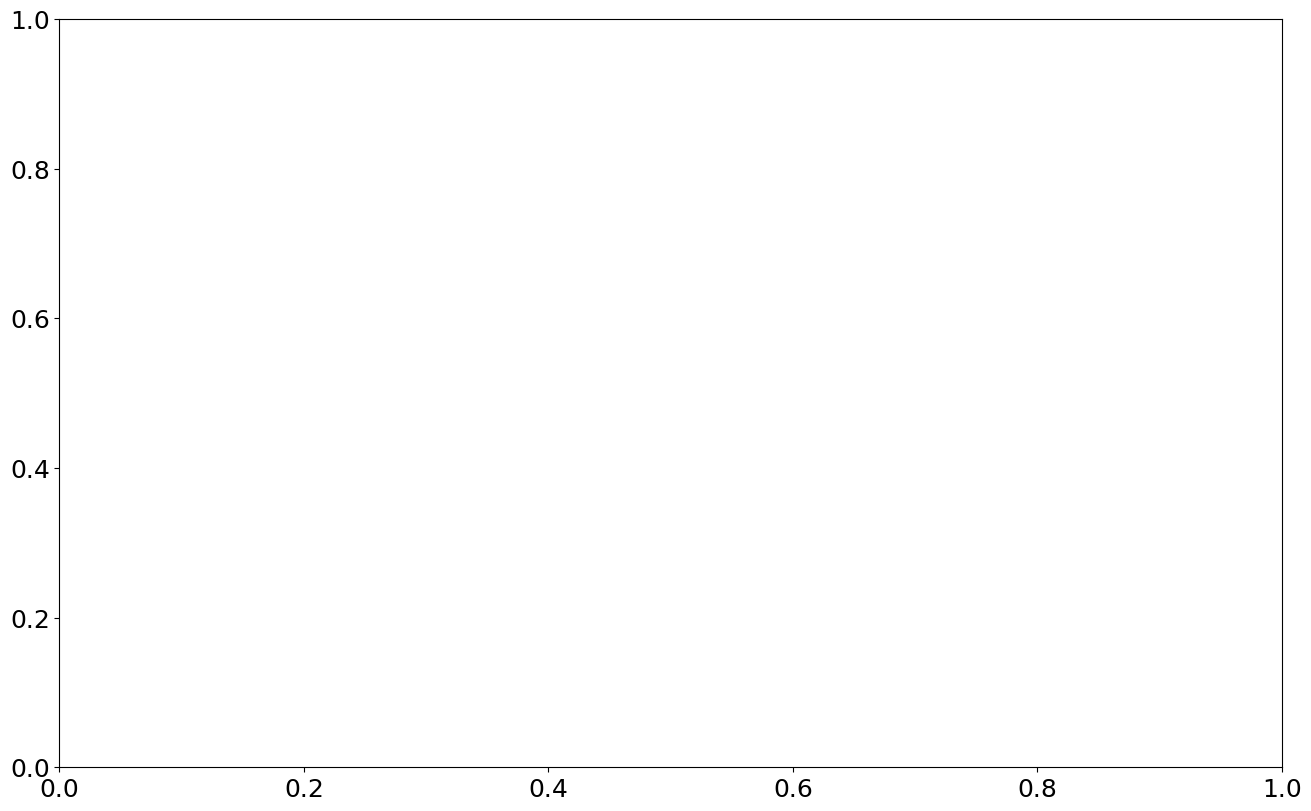

In [65]:
'''
Z500 max/min scatter: Nino3.4 SSTA vs spatial max and min of seasonal mean Z500 anomaly
in z500_scatter_region.  One point per NDJFM season.
Smoothing splines fitted per case through the max and min clouds (solid/dashed).
One legend entry per case.
'''
from scipy.interpolate import UnivariateSpline

if collected_z500_scatter:
    fig_zsc, ax_zsc = plt.subplots(1, 1, figsize=(13, 8), constrained_layout=True)

    for d in collected_z500_scatter:
        lbl  = f"{d['display_name']} ({d['yr0']}-{d['yr1']})"
        col  = d['col']
        mrk  = d['marker']

        # ── scatter points (label only on max so each case appears once) ────
        ax_zsc.scatter(d['ssta'], d['z500_max'], color=col, alpha=0.35, s=20,
                       marker=mrk, label=lbl)
        ax_zsc.scatter(d['ssta'], d['z500_min'], color=col, alpha=0.35, s=20,
                       marker=mrk, label='_nolegend_')

        # ── splines through this case's max and min clouds ───────────────────
        for z500_pts, ls in [(d['z500_max'], '-'), (d['z500_min'], '--')]:
            sort_idx = np.argsort(d['ssta'])
            xs       = d['ssta'][sort_idx]
            ys       = z500_pts[sort_idx]
            spl      = UnivariateSpline(xs, ys, k=3, s=len(xs) * np.var(ys) * 2)
            x_fine   = np.linspace(xs[0], xs[-1], 300)
            ax_zsc.plot(x_fine, spl(x_fine), color=col, linewidth=2.5,
                        linestyle=ls, zorder=5, label='_nolegend_')

    ax_zsc.axhline(0., color='gray', linestyle='--', linewidth=1.2)
    ax_zsc.axvline(0., color='gray', linestyle='--', linewidth=1.2)
    ax_zsc.set_xlabel(f'{xnino_reg} SST anomaly (K)', fontsize=13)
    ax_zsc.set_ylabel(f'Z500 anomaly in {z500_scatter_region} (m)', fontsize=13)
    ax_zsc.set_title(f'Z500 seasonal mean anomaly range vs {xnino_reg} SSTA — {season}', fontsize=13)
    lgnd_zsc = ax_zsc.legend(loc='upper left', fontsize=9, framealpha=0.8,
                              title='— max   -- min', title_fontsize=8)
    ax_zsc.grid(True, alpha=0.35)

    fig_zsc.savefig(
        dir_fig + (fig_pref_user+'_' if fig_pref_user else '') + 'Z500_maxmin_scatter_' + season + '_' + xnino_reg + '.png',
        dpi=150, bbox_inches='tight')
    fig_zsc.show()
    plt.close(fig_zsc)
else:
    print('No Z500 scatter data collected — set lz500_scatter=True in the case specs cell.')

In [ ]:
'''
Z500 EOF PC1 scatter: Nino3.4 SSTA vs PC1 score of the leading EOF of seasonal mean
Z500 anomaly in z500_scatter_region.  One point per NDJFM season.
PC1 is signed so that positive values correspond to El Niño (positive SSTA).
Variance explained by EOF1 is shown in the legend.
Spline fit per case.
'''
from scipy.interpolate import UnivariateSpline

if collected_z500_scatter and all('pc1' in d for d in collected_z500_scatter):
    fig_eof, ax_eof = plt.subplots(1, 1, figsize=(13, 8), constrained_layout=True)

    for d in collected_z500_scatter:
        col = d['col']
        mrk = d['marker']
        lbl = f"{d['display_name']} ({d['yr0']}-{d['yr1']})  VE={d['var_exp']:.0f}%"

        # ── scatter: one point per season ────────────────────────────────────
        ax_eof.scatter(d['ssta'], d['pc1'], color=col, alpha=0.4, s=25,
                       marker=mrk, label=lbl)

        # ── spline fit ───────────────────────────────────────────────────────
        sort_idx = np.argsort(d['ssta'])
        xs = d['ssta'][sort_idx]
        ys = d['pc1'][sort_idx]
        spl = UnivariateSpline(xs, ys, k=3, s=len(xs) * np.var(ys) * 2)
        x_fine = np.linspace(xs[0], xs[-1], 300)
        ax_eof.plot(x_fine, spl(x_fine), color=col, linewidth=2.5, zorder=5)

    ax_eof.axhline(0., color='gray', linestyle='--', linewidth=1.2)
    ax_eof.axvline(0., color='gray', linestyle='--', linewidth=1.2)
    ax_eof.set_xlabel(f'{xnino_reg} SST anomaly (K)', fontsize=13)
    ax_eof.set_ylabel(f'Z500 EOF1 PC score in {z500_scatter_region}', fontsize=13)
    ax_eof.set_title(
        f'Z500 leading EOF PC1 vs {xnino_reg} SSTA — {season}\n'
        f'(region: {z500_scatter_region};  sign: PC1>0 = El Niño-like)',
        fontsize=13)
    ax_eof.legend(loc='upper left', fontsize=9, framealpha=0.8,
                  title='VE = var. exp. EOF1', title_fontsize=8)
    ax_eof.grid(True, alpha=0.35)

    fig_eof.savefig(
        dir_fig + (fig_pref_user+'_' if fig_pref_user else '') + 'Z500_EOF1_scatter_' + season + '_' + xnino_reg + '.png',
        dpi=150, bbox_inches='tight')
    fig_eof.show()
    plt.close(fig_eof)
else:
    print('No EOF PC1 data found — re-run the main loop with lz500_scatter=True.')